In [43]:
from tripodpy import Simulation
import numpy as np 
import csv
import matplotlib.pyplot as plt
import dustpy.constants as c

In [44]:
sim = Simulation()

In [45]:
sim.initialize()

In [46]:

with open("test_sim.csv", "w", newline="") as f:
    writer = csv.writer(f)


    for row in zip(sim.grid.r,sim.grid.OmegaK,sim.gas.Sigma,sim.gas.cs,sim.gas.Hp,sim.gas.T,sim.gas.mu,sim.gas.mfp,sim.gas.eta,sim.gas.P):
        writer.writerow(row)

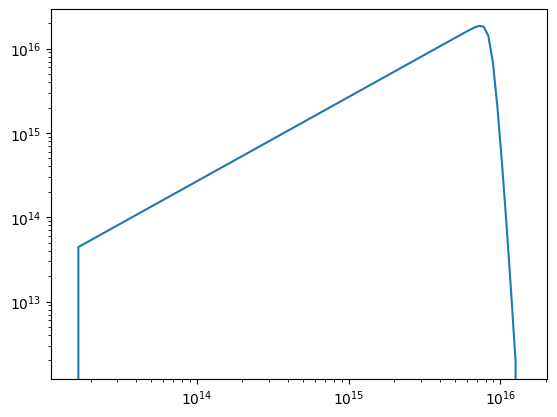

In [47]:
plt.figure()
plt.loglog(sim.grid.r,sim.dust.D[:,2])

In [48]:
sim.dust.D[:4,2]

[0.00000000e+00 4.42816271e+13 4.74486183e+13 5.08421105e+13]

In [49]:
sim.t.snapshots = [1e2*c.year]
sim.gas.nu = 0e0 
sim.gas.nu.updater = None

In [50]:
sim.writer.overwrite = True
sim.run()


tripodpy v1.0.0

Writing file data/data0000.hdf5
Writing dump file data/frame.dmp
Execution time: 0:00:00


In [51]:
sim.grid.ri[-1]/c.au

np.float64(999.999999999997)

In [52]:
sim.ini

namespace(dust=namespace(aIniMax=0.0001,
                         allowDriftingParticles=False,
                         d2gRatio=0.01,
                         distExp=-3.5,
                         rhoMonomer=1.67,
                         vFrag=100.0),
          gas=namespace(alpha=0.001,
                        Mdisk=9.942049353490256e+31,
                        mu=3.847030424486999e-24,
                        SigmaExp=-1.0,
                        SigmaRc=897587224200000.0),
          grid=namespace(mmin=1e-12,
                         Nr=100,
                         rmin=14959787070000.0,
                         rmax=1.495978707e+16),
          star=namespace(M=1.988409870698051e+33, R=139140000000.0, T=5772.0))

In [53]:
sim.dust.s.min

[5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.228755

In [54]:
import pandas as pd

df = pd.read_csv("tri.outputdat", sep=r"\s+", header=None)

df2 = pd.read_csv("tri_0003.outputdat", sep=r"\s+", header=None)

In [55]:
df2.shape

(100, 7)

In [56]:
df2[6]/c.year

0     100.000001
1     100.000001
2     100.000001
3     100.000001
4     100.000001
         ...    
95    100.000001
96    100.000001
97    100.000001
98    100.000001
99    100.000001
Name: 6, Length: 100, dtype: float64

In [57]:
sim.t/c.year

100.0

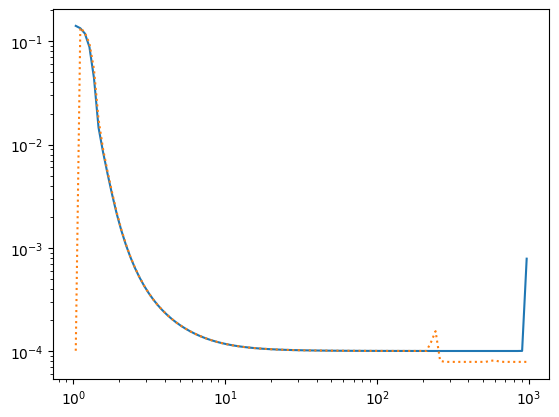

In [58]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.s.max)
#plt.loglog(df[1]/c.au,df[4],"--")
plt.loglog(df2[1]/c.au,df2[4],":")

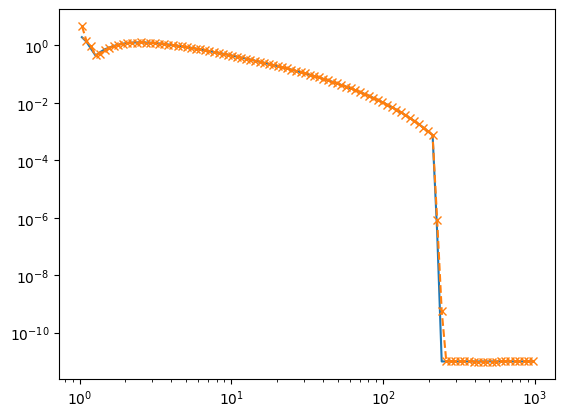

In [59]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,0])
plt.loglog(df2[1]/c.au,df2[2],"x--")
#plt.ylim(1e-4,1e4)

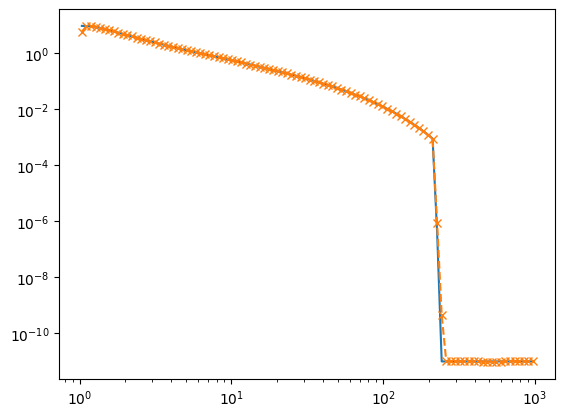

In [60]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1])
plt.loglog(df2[1]/c.au,df2[3],"x--")

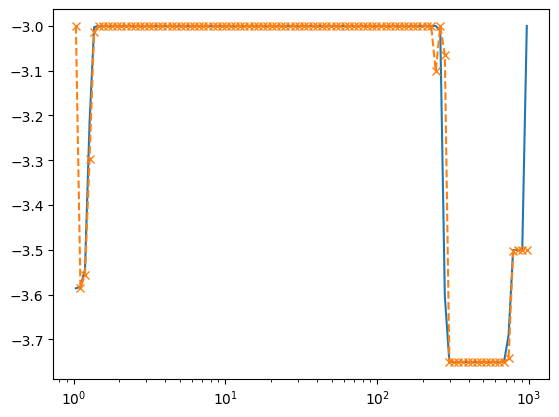

In [61]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.q.eff[:])
plt.plot(df2[1]/c.au,df2[5],"x--")
plt.xscale("log")

In [62]:
sim.dust.q

Group (Distribution exponents)
------------------------------
    drfrag       : Field (Size distribution exponent in drift-induced fragmentation regime)
    eff          : Field (Calculated distribution exponent)
    frag         : Field (Fragmentation distribution exponent)
    sweep        : Field (Size distribution exponent in the sweep-up regime)
    turb1        : Field (Size distribution exponent in first turbulence regime)
    turb2        : Field (Size distribution exponent in second turbulence regime)
  -----

In [63]:
import numpy as np
import scipy.sparse as sp

data = np.array([1, 2, 3, 4,-4])
row  = np.array([0, 0, 1, 0,0])
col  = np.array([1, 1, 2, 1,1])

A = sp.csc_matrix((data, (row, col)), shape=(3, 3))



In [64]:
print(A.toarray())

[[0 3 0]
 [0 0 3]
 [0 0 0]]
